In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import torch
from torch_geometric.data import HeteroData

In [13]:
with open("../data/03-result/merged_df.pkl","rb") as f:
    merged_df =pickle.load(f)
with open("../data/03-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/03-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)

In [ ]:
# Consider dropping name embedding similarity since it contains SPOILERS
merged_df = merged_df.drop(columns = ["name_similarity"])

# Prepare train and test set

In [15]:
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]

num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)

# Preprocessor

In [16]:
# NOTE: normally imputation is already done in previous steps
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Models definition

In [17]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(class_weight='balanced',n_estimators=300))
])

gb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("gb", GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05))
])

knn_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=20))
])

logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500))
])

lasso_logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500, penalty="l1", solver="liblinear"))
])

ridge_logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500, penalty="l2", solver="liblinear"))
])

linear_svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="linear"))
    ])

poly_svm_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="poly"))
    ])

rbf_svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="rbf"))
    ])

# Fit and predict

In [18]:
model = gb_model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

if hasattr(model, "predict_proba") and callable(getattr(model, "predict_proba")):
    y_proba = model.predict_proba(X_test)[:, 1]
else:
    print("This model doesn't yeild probabilities")
    y_proba = None

# Evaluate

- TODO: balanced_accuracy score
- TODO: see wikipedian evalution metrics forbinary classification
- TODO: check imbalanced_learn module 

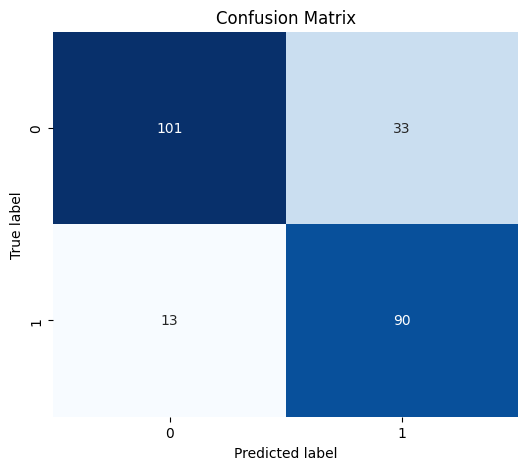

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
print("  Accuracy:", accuracy_score(y_test, y_pred))
print("  Precision:", precision_score(y_test, y_pred))
print("  Recall:", recall_score(y_test, y_pred))
print("  F1 score:", f1_score(y_test, y_pred))
if y_proba is not None:
    print("  AUC:", roc_auc_score(y_test, y_proba))

  Accuracy: 0.8059071729957806
  Precision: 0.7317073170731707
  Recall: 0.8737864077669902
  F1 score: 0.7964601769911505
  AUC: 0.9096507752499637


# Feature importance

## Model agnostic feature importance

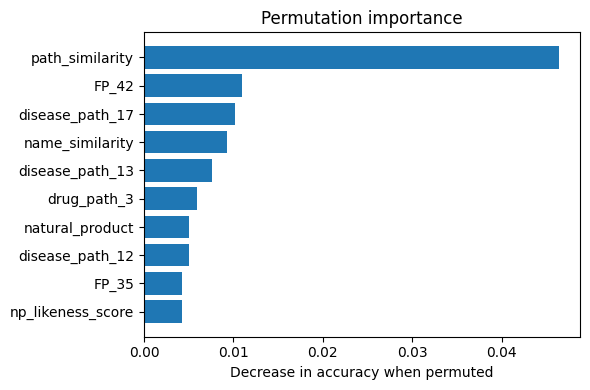

In [21]:
perm_imp = permutation_importance(estimator=model, X=X_test, y=y_test, n_repeats=5)

# Compute a dataframe to sum up the results
perm_importances = pd.DataFrame({
    "feature" : X.columns,#pipe_log.feature_names_in_,
    "mean_importance" : perm_imp["importances_mean"],
    "std_importance" : perm_imp["importances_std"]
})
perm_importances.sort_values(by="mean_importance", ascending=False, inplace=True, ignore_index=True)
plt.figure(figsize=(6, 4))
plt.barh(perm_importances["feature"][:10][::-1], perm_importances["mean_importance"][:10][::-1])
plt.xlabel("Decrease in accuracy when permuted")
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

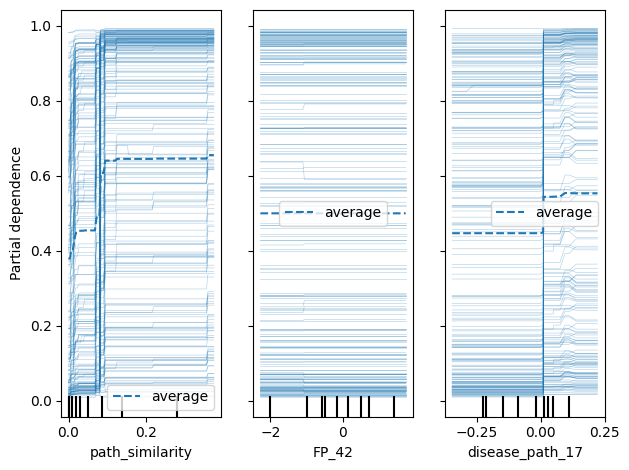

In [22]:
feature_to_plot = perm_importances["feature"][:3].tolist()
target_class = 1                        

PartialDependenceDisplay.from_estimator(
    estimator=model,
    X = X_test,
    target=target_class,
    features = feature_to_plot,
    kind="both"
)
plt.tight_layout()
plt.show()

In [23]:
features_2d = [tuple(perm_importances["feature"][:2])]

PartialDependenceDisplay.from_estimator(
    estimator=model,
    X = X_test,
    target=target_class,
    features=features_2d
)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## Model-specific feature importance

In [ ]:
num_features = list(num_cols)
cat_features = list(cat_cols)
all_features = num_features + cat_features

if "rf" in model.named_steps:
    rf = model.named_steps["rf"]

    
    importances = rf.feature_importances_
    rf_feature_importance = pd.DataFrame({
        "feature": all_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False)
    print(rf_feature_importance)
elif "logreg" in model.named_steps:
    logreg = model.named_steps["logreg"]
    coef = logreg.coef_[0]  
    logreg_feature_importance = pd.DataFrame({
        "feature": all_features,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values(by="abs_coef", ascending=False)

    print(logreg_feature_importance)

             feature  importance
222  path_similarity    0.031618
175   disease_path_3    0.025963
189  disease_path_17    0.025352
185  disease_path_13    0.019376
176   disease_path_4    0.019127
..               ...         ...
3             orphan    0.000140
17          ro3_pass    0.000133
5         veterinary    0.000037
71    chirality__nan    0.000000
1     inorganic_flag    0.000000

[223 rows x 2 columns]


# TODO: PU / semi-supervized models 
# TODO: node2vec to generate features

# Heterogenous Graph Model

https://pytorch-geometric.readthedocs.io/en/2.6.0/notes/heterogeneous.html

Example schema:

```py
HeteroData(
  paper={
    x=[736389, 128],
    y=[736389],
    train_mask=[736389],
    val_mask=[736389],
    test_mask=[736389]
  },
  author={ x=[1134649, 128] },
  institution={ x=[8740, 128] },
  field_of_study={ x=[59965, 128] },
  (author, affiliated_with, institution)={ edge_index=[2, 1043998] },
  (author, writes, paper)={ edge_index=[2, 7145660] },
  (paper, cites, paper)={ edge_index=[2, 5416271] },
  (paper, has_topic, field_of_study)={ edge_index=[2, 7505078] }
)
```

Take data from:

- unique pathways from `drugs_df["drug_pathways"]`, `diseases_df["disease_pathways"]`
    - →  **pathway nodes**

- `drugs_df` 
    - →  **drug nodes**
    - →  feature vector: from `FP_...` and other non-path columns
    - →  **edges drug-pathway** from lists `drug_pathways`
    
- `diseases_df` 
    - →  **disease nodes**
    - →  feature vector: from non-path columns (probably none)
    - →  **edges disese-pathway** from lists `disease_pathways`

- `merged_df` 
    - →  **edges drug-disease** labeled by `success`

Nodes:

In [135]:
drug_features = drugs_df.drop(columns = drugs_df.filter(regex="path").columns)
drug_features = drug_features.select_dtypes(include=["number", "bool"])
drug_features = torch.tensor( drug_features.values.astype(np.float64), dtype=torch.float)

# NOTE: diseases have no informative numeric features, they will be just bare node
num_diseases = diseases_df.shape[0]

all_pathways = np.array( list(set(drugs_df["drug_pathways"].explode()) | set(diseases_df["disease_pathways"].explode())), dtype=str)
num_pathways = len(all_pathways)

Keep track of ROW ids:

In [136]:
path2id = {p: i for i, p in enumerate(all_pathways)}
drug2id = {row["drug_id"]:i for i, row in drugs_df.iterrows()}
disease2id = {row["disease_id"]:i for i, row in diseases_df.iterrows()}

Edges:

In [137]:
drug_pathway_edges = []
for _, row in drugs_df.iterrows():
    for path in row["drug_pathways"]:
        drug_id = drug2id[row["drug_id"]]
        path_id = path2id[path]
        drug_pathway_edges.append([drug_id, path_id])

drug_pathway_edges = torch.tensor(drug_pathway_edges, dtype=torch.long).t().contiguous()

disease_pathway_edges = []
for _, row in diseases_df.iterrows():
    for path in row["disease_pathways"]:
        disease_id = disease2id[row["disease_id"]]
        path_id = path2id[path]
        disease_pathway_edges.append([disease_id, path_id])

disease_pathway_edges = torch.tensor(disease_pathway_edges, dtype=torch.long).t().contiguous()

In [138]:
drug_disease_edges = []
drug_disease_edge_attr = []

for _, row in merged_df.iterrows():
    drug_id = drug2id[row["drug_id"]]
    disease_id = disease2id[row["disease_id"]]
    drug_disease_edges.append([drug_id, disease_id])
    drug_disease_edge_attr.append(int(row["success"]))


drug_disease_edges = torch.tensor(drug_disease_edges, dtype=torch.long).t().contiguous()

drug_disease_edge_attr = torch.tensor(drug_disease_edge_attr, dtype=torch.float).unsqueeze(1)

Build the graph:

In [143]:
graph_data = HeteroData()

graph_data["drug"].x = drug_features
graph_data["disease"].x = torch.ones( (num_diseases, 1) ) # dummy features
graph_data["pathway"].x = torch.ones( (num_pathways, 1))

graph_data['drug', 'interacts', 'pathway'].edge_index = drug_pathway_edges
graph_data['disease', 'associated_with', 'pathway'].edge_index = disease_pathway_edges
graph_data['drug', 'tryed_against', 'disease'].edge_index = drug_disease_edges
graph_data['drug', 'tryed_against', 'disease'].edge_attr = drug_disease_edge_attr

graph_data


HeteroData(
  drug={ x=[742, 127] },
  disease={ x=[196, 1] },
  pathway={ x=[1553, 1] },
  (drug, interacts, pathway)={ edge_index=[2, 31266] },
  (disease, associated_with, pathway)={ edge_index=[2, 16882] },
  (drug, tryed_against, disease)={
    edge_index=[2, 1183],
    edge_attr=[1183, 1],
  }
)

### GNN edge-level prediction